In [10]:
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader
import numpy as np
import os
from scipy.stats import wilcoxon, ranksums, ttest_rel, binomtest
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from matplotlib_venn import venn2
from iblatlas.atlas import AllenAtlas   
import matplotlib.pyplot as plt
import seaborn as sns


tag = 'Brainwidemap'
from one import params as one_params
one_params.setup(
    client='https://openalyx.internationalbrainlab.org',
    cache_dir=r'Z:\ibl_brain_wide_map',
    make_default=True,
    silent=True
)
one = ONE(
    base_url='https://openalyx.internationalbrainlab.org',
    cache_dir=r'Z:\ibl_brain_wide_map'  # your network drive
)

ba = AllenAtlas()

In [11]:
# Parameters 
brain_regions = ['PF']
stimulus_windows = [[0, 0.1]] # time window for stimulus
baseline_window = [-0.1, 0] # time window for baseline
time_bins = np.arange(-0.1, 0.3, 0.01)  # 10 ms bins for psth



hemi contralateral vs ipsilateral (recording side)

In [ ]:
# MATTHIAS VERSION


os.makedirs('png', exist_ok=True)
os.makedirs('eps', exist_ok=True)

# loop over brain regions
for brain_acronym in brain_regions:
    
    # loop over stimulus windows
    for stimulus_window in stimulus_windows:

        insertions = one.search_insertions(atlas_acronym=brain_acronym, tag=tag)
        print(f' No. of insertions: {len(insertions)}')

        psth_contra_all_clusters = np.empty((0, len(time_bins)))
        psth_ipsi_all_clusters = np.empty((0, len(time_bins)))

        # make a cluster_df_all dataframe to store the results for all clusters
        cluster_df_all = pd.DataFrame(columns=['cluster_id', 'eid', 'atlas_id', 'x', 'y', 'z', 'brain_area_label', 'mean_fr_contra', 'mean_fr_ipsi', 'p_contra', 'p_ipsi', 'p_contra_ipsi'])

        # for loop over insertions
        for i, insertion in enumerate(insertions):

            # print insertion number
            print(f'Insertion {i+1}/{len(insertions)}')

            pid = insertion
            eid, _ = one.pid2eid(pid)

            # load trial data
            obj = 'trials'
            trials = one.load_object(eid, obj)
            print(trials.keys())

            # compute response times by subtracting stimOn_times from response_times
            trials['response_times'] = trials['response_times'] - trials['stimOn_times']

            # get stimulus onset times for left and right high contrast stimuli, feedbackType must be 1 (rewarded) and response_times < 2
            left_stimOn_times = trials['stimOn_times'][(trials['contrastLeft'] == 1) & (trials['feedbackType'] == 1) & (trials['response_times'] < 2)]
            right_stimOn_times = trials['stimOn_times'][(trials['contrastRight'] == 1) & (trials['feedbackType'] == 1) & (trials['response_times'] < 2)]

            # load spike data
            spike_loader = SpikeSortingLoader(pid=pid, one=one)
            spikes, clusters, channels = spike_loader.load_spike_sorting()
            clusters = spike_loader.merge_clusters(spikes, clusters, channels)

            if brain_acronym == 'VISp':
                # Only include clusters with label == 1 and acronyms that equal 'VISp' or start with 'VISp' followed by a number.
                valid_acronym = [acronym == 'VISp' or (acronym.startswith('VISp') and len(acronym) > 4 and acronym[4].isdigit())
                                 for acronym in clusters['acronym'].astype(str)]
                clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1, np.array(valid_acronym)))[0]
            # else if brain_acronym == 'PF', cluster acronyms should match PF exactly
            elif brain_acronym == 'PF':
                clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1,
                                                     clusters['acronym'].astype(str) == brain_acronym))[0]
            else:
                clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1,
                                                         np.char.startswith(clusters['acronym'].astype(str), brain_acronym)))[0]
            
            spikes_idx = np.isin(spikes.clusters, clusters_idx)

            clusters_roi = {k: v[clusters_idx] for k, v in clusters.items()}
            spikes_roi = {k: v[spikes_idx] for k, v in spikes.items()}

            for clust in clusters_roi['cluster_id']:
                
                # get spike times for this cluster
                spike_times = spikes_roi['times'][spikes_roi['clusters'] == clust]

                # if x coordinate is negative save left_stimOn_times as ipsi_stimOn_times and right_stimOn_times as contra_stimOn_times
                # if x coordinate is positive save left_stimOn_times as contra_stimOn_times and right_stimOn_times as ipsi_stimOn_times
                if clusters_roi['x'][clusters_roi['cluster_id'] == clust] < 0:
                    ipsi_stimOn_times = left_stimOn_times
                    contra_stimOn_times = right_stimOn_times
                else:
                    ipsi_stimOn_times = right_stimOn_times
                    contra_stimOn_times = left_stimOn_times


                ## confirm atlas location of the cluster
                mlapdv = np.c_[clusters_roi["x"][clusters_roi['cluster_id'] == clust], clusters_roi["y"][clusters_roi['cluster_id'] == clust], clusters_roi["z"][clusters_roi['cluster_id'] == clust]]
                area_label = ba.get_labels(mlapdv, mapping="Allen-lr")

                ## CONTRALATERAL STIMULI ##

                # initialize empty array for psth_contra
                psth_contra= np.empty((0, len(time_bins)-1))
                baseline_spikes_contra= np.empty((0, 1))
                stimulus_spikes_contra= np.empty((0, 1))

                for contra_stimulus in contra_stimOn_times:
                    
                    # PSTH
                    # get the psth for this cluster and contra stimulus
                    psth = np.histogram(spike_times, bins=time_bins+contra_stimulus)
                    # append psth to array for this cluster
                    psth_contra = np.vstack((psth_contra, psth[0]))

                    # get number of spikes in the baseline window
                    baseline_spikes = np.histogram(spike_times, bins=baseline_window+contra_stimulus)[0]
                    stimulus_spikes = np.histogram(spike_times, bins=stimulus_window+contra_stimulus)[0]
                    # append baseline_spikes to baseline_spikes_contra array
                    baseline_spikes_contra = np.vstack((baseline_spikes_contra, baseline_spikes))
                    # append stimulus_spikes to stimulus_spikes_contra array
                    stimulus_spikes_contra = np.vstack((stimulus_spikes_contra, stimulus_spikes))

                ## IPSILATERAL STIMULI ##

                # initialize empty array for psth_ipsi
                psth_ipsi = np.empty((0, len(time_bins)-1))
                baseline_spikes_ipsi = np.empty((0, 1))
                stimulus_spikes_ipsi = np.empty((0, 1))

                for ipsi_stimulus in ipsi_stimOn_times:
                    
                    # PSTH
                    # get the psth for this cluster and ipsi stimulus
                    psth = np.histogram(spike_times, bins=time_bins+ipsi_stimulus)
                    # append psth to array for this cluster
                    psth_ipsi = np.vstack((psth_ipsi, psth[0]))

                    # get number of spikes in the baseline window
                    baseline_spikes = np.histogram(spike_times, bins=baseline_window+ipsi_stimulus)[0]
                    stimulus_spikes = np.histogram(spike_times, bins=stimulus_window+ipsi_stimulus)[0]
                    # append baseline_spikes to baseline_spikes_ipsi array
                    baseline_spikes_ipsi = np.vstack((baseline_spikes_ipsi, baseline_spikes))
                    # append stimulus_spikes to stimulus_spikes_ipsi array
                    stimulus_spikes_ipsi = np.vstack((stimulus_spikes_ipsi, stimulus_spikes))


                # summary statistics for this cluster and statistical tests

                ## PSTH CONTRALATERAL ##
                # compute the mean of the psth_contra array along axis 0 (across trials)
                psth_contra = np.mean(psth_contra, axis=0)

                # make psth_contra a row vector
                psth_contra = np.reshape(psth_contra, (1, -1))
                # add the cluster id to the psth_contra array
                psth_contra = np.hstack((np.full((psth_contra.shape[0], 1), clust), psth_contra))
                # add psth_contra to the psth_contra_all_clusters array
                psth_contra_all_clusters = np.vstack((psth_contra_all_clusters, psth_contra))

                ## PSTH IPSILATERAL ##
                # compute the mean of the psth_ipsi array along axis 0 (across trials)
                psth_ipsi = np.mean(psth_ipsi, axis=0)
                # make psth_ipsi a row vector
                psth_ipsi = np.reshape(psth_ipsi, (1, -1))
                # add the cluster id to the psth_ipsi array
                psth_ipsi = np.hstack((np.full((psth_ipsi.shape[0], 1), clust), psth_ipsi))
                # add psth_ipsi to the psth_ipsi_all_clusters array
                psth_ipsi_all_clusters = np.vstack((psth_ipsi_all_clusters, psth_ipsi))

                ## Binned firing rate ##
                stimulus_firing_rate_contra = stimulus_spikes_contra / (stimulus_window[1] - stimulus_window[0])
                stimulus_firing_rate_ipsi = stimulus_spikes_ipsi / (stimulus_window[1] - stimulus_window[0])
                baseline_firing_rate_contra = baseline_spikes_contra / (baseline_window[1] - baseline_window[0])
                baseline_firing_rate_ipsi = baseline_spikes_ipsi / (baseline_window[1] - baseline_window[0])

                # non-parametric paired-test between baseline and stimulus window
                p_contra = wilcoxon(stimulus_firing_rate_contra,baseline_firing_rate_contra, alternative='greater').pvalue[0]
                p_ipsi = wilcoxon(stimulus_firing_rate_ipsi,baseline_firing_rate_ipsi, alternative='greater').pvalue[0]

                # non-parametric two-sample test between contra and ipsi stimulus (rank sum test)
                p_contra_ipsi = ranksums(stimulus_firing_rate_contra, stimulus_firing_rate_ipsi).pvalue[0]

                # compute mean firing rate for contra and ipsi stimulus
                mean_firing_rate_contra = np.mean(stimulus_firing_rate_contra)
                mean_firing_rate_ipsi = np.mean(stimulus_firing_rate_ipsi)
                
                # store p_contra, p_ipsi and p_contra_ipsi in a pandas data frame 
                # together with the cluster id, the eid, and x, y and z coordinates of the cluster
                cluster_df = pd.DataFrame({'cluster_id': clust, 'eid': eid, 'atlas_id': clusters_roi['atlas_id'][clusters_roi['cluster_id']==clust], 'x': clusters_roi['x'][clusters_roi['cluster_id']==clust], 'y': clusters_roi['y'][clusters_roi['cluster_id']==clust], 'z': clusters_roi['z'][clusters_roi['cluster_id']==clust], 'brain_area_label': area_label, 'mean_fr_contra': mean_firing_rate_contra, 'mean_fr_ipsi': mean_firing_rate_ipsi, 'p_contra': p_contra, 'p_ipsi': p_ipsi, 'p_contra_ipsi': p_contra_ipsi}, index=[0])

                # append cluster_df to the dataframe
                cluster_df_all = pd.concat([cluster_df_all, cluster_df], ignore_index=True)
                

        # avarage psth_contra across all clusters (column 0 is cluster id)
        mean_psth_contra_all_clusters = np.mean(psth_contra_all_clusters[:, 1:], axis=0) / 0.01  # divide by bin size to get firing rate in Hz
        # same for psth_ipsi
        mean_psth_ipsi_all_clusters = np.mean(psth_ipsi_all_clusters[:, 1:], axis=0) / 0.01  # divide by bin size to get firing rate in Hz

        # plot psth_contra and psth_ipsi
        sns.set(style="whitegrid")
        plt.figure(figsize=(6, 5))
        plt.plot(time_bins[:-1], mean_psth_contra_all_clusters, label='contra stimulus', color='blue')
        plt.plot(time_bins[:-1], mean_psth_ipsi_all_clusters, label='ipsi stimulus', color='red')
        plt.axvline(x=0, color='grey', linestyle='--')
        plt.axvline(x=stimulus_window[0], color='black', linestyle='--')
        plt.axvline(x=stimulus_window[1], color='black', linestyle='--')
        plt.xlabel('Time (s)')
        plt.ylabel('Firing rate (Hz)')
        # title with brain region and stimulus window
        plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
        # add a legend
        plt.legend()
        # save plot to file as eps and png
        plt.savefig(f'png/{brain_acronym}_PSTH_{stimulus_window[0]}_{stimulus_window[1]}.png', format='png')
        plt.savefig(f'eps/{brain_acronym}_PSTH_{stimulus_window[0]}_{stimulus_window[1]}.eps', format='eps')

        # compute proportion of clusters that are significantly modulated by contra and ipsi stimuli
        contra_modulated = np.sum(np.bitwise_and(cluster_df_all['p_contra'] < 0.05, cluster_df_all['p_ipsi'] > 0.05)) / len(cluster_df_all)
        ipsi_modulated = np.sum(np.bitwise_and(cluster_df_all['p_contra'] > 0.05, cluster_df_all['p_ipsi'] < 0.05)) / len(cluster_df_all)
        print(f'Proportion of clusters modulated by contra stimulus: {contra_modulated:.2f}')
        print(f'Proportion of clusters modulated by ipsi stimulus: {ipsi_modulated:.2f}')

        # proportion of clusters that are significantly modulated by both contra and ipsi stimuli
        both_modulated = np.sum(np.bitwise_and(cluster_df_all['p_contra'] < 0.05, cluster_df_all['p_ipsi'] < 0.05)) / len(cluster_df_all)
        print(f'Proportion of clusters modulated by both contra and ipsi stimuli: {both_modulated:.2f}')

        # conduct one sample z-test for proportion to compare contra_modulated proportion to 0.05
        _, p_value_contra = proportions_ztest(contra_modulated*len(cluster_df_all), len(cluster_df_all), value=0.05,alternative='larger',prop_var=0.05)
        _, p_value_ipsi = proportions_ztest(ipsi_modulated*len(cluster_df_all), len(cluster_df_all), value=0.05,alternative='larger',prop_var=0.05)
        _, p_value_both = proportions_ztest(both_modulated*len(cluster_df_all), len(cluster_df_all), value=0.05,alternative='larger',prop_var=0.05)

        # statistically compare contra_modulated and ipsi_modulated proportions using binomial test
        n_contra = np.sum(np.bitwise_and(cluster_df_all['p_contra'] < 0.05, cluster_df_all['p_ipsi'] > 0.05))
        n_ipsi = np.sum(np.bitwise_and(cluster_df_all['p_contra'] > 0.05, cluster_df_all['p_ipsi'] < 0.05))
        p_contra_vs_ipsi = binomtest(n_contra, n_contra+n_ipsi, p=0.5, alternative='two-sided').pvalue

        # make a bar plot of the proportion of clusters modulated by contra and ipsi stimuli
        plt.figure(figsize=(5, 5))
        plt.bar(['Contra-responsive', 'Ipsi-responsive', 'Both-responsive'], [contra_modulated, ipsi_modulated, both_modulated], color=['blue', 'red', 'purple'])
        # add the numbers above each bar
        for i, v in enumerate([contra_modulated, ipsi_modulated, both_modulated]):
            plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')
        # add p_vavlue_contra, p_value_ipsi and p_value_both to the plot
        plt.text(0, 0.45, f'p-value contra: {p_value_contra:.4f}', ha='center', va='bottom', fontsize=8, color='blue')
        plt.text(1, 0.45, f'p-value ipsi: {p_value_ipsi:.4f}', ha='center', va='bottom', fontsize=8, color='red')
        plt.text(2, 0.45, f'p-value both: {p_value_both:.4f}', ha='center', va='bottom', fontsize=8, color='purple')
        # add p_value_contra_vs_ipsi to the plot (shift a bit down)
        plt.text(0.5, 0.35, f'p-value contra vs ipsi: {p_contra_vs_ipsi:.4f}', ha='center', va='bottom', fontsize=8, color='black')
        # draw a dashed horizontal line at y=0.05
        plt.axhline(y=0.05, color='black', linestyle='--')
        plt.ylabel('Proportion of clusters')
        # title with brain region and stimulus window
        plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
        plt.ylim(0, 0.5)
        plt.xticks(rotation=45)
        plt.grid()
        # save plot to file as eps and png. Avoid cutting off the text by using bbox_inches='tight'
        plt.savefig(f'png/{brain_acronym}_Modulation_barplot_{stimulus_window[0]}_{stimulus_window[1]}.png', format='png', bbox_inches='tight')
        plt.savefig(f'eps/{brain_acronym}_Modulation_barplot_{stimulus_window[0]}_{stimulus_window[1]}.eps', format='eps', bbox_inches='tight')
        plt.show()

        # make a venn diagram of the proportions of clusters modulated by contra and ipsi stimuli
        subsets = (round(contra_modulated*100,2), round(ipsi_modulated*100,2), round(both_modulated*100,2))
        plt.figure(figsize=(5, 5))
        venn2(subsets=subsets, set_labels=('Contra-responsive', 'Ipsi-responsive'))
        # title with brain region and stimulus window
        plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
        # save plot to file as eps
        plt.savefig(f'png/{brain_acronym}_Modulation_Venn_{stimulus_window[0]}_{stimulus_window[1]}.png', format='png')
        plt.savefig(f'eps/{brain_acronym}_Modulation_Venn_{stimulus_window[0]}_{stimulus_window[1]}.eps', format='eps')
        plt.show()

        # proportion of clusters with significant p_contra_ipsi
        # (i.e. significant difference between contra and ipsi stimuli)
        contra_ipsi_modulated = np.sum(cluster_df_all['p_contra_ipsi'] < 0.05) / len(cluster_df_all)
        print(f'Proportion of clusters modulated by contra versus ipsi stimuli: {contra_ipsi_modulated:.2f}')
        _, p_value_contra_ipsi_modulated = proportions_ztest(contra_ipsi_modulated*len(cluster_df_all), len(cluster_df_all), value=0.05,alternative='larger',prop_var=0.05)

        # add column to cluster_df_all with the difference between contra and ipsi mean firing rates
        cluster_df_all['mean_fr_diff'] = cluster_df_all['mean_fr_contra'] - cluster_df_all['mean_fr_ipsi']

        # what's the proportion of clusters with significant p_contra_ipsi and positive mean_fr_diff
        pos_mean_fr_diff = np.sum(np.bitwise_and(cluster_df_all['mean_fr_diff'] > 0, cluster_df_all['p_contra_ipsi'] < 0.05)) / len(cluster_df_all)
        print(f'Proportion of clusters with positive mean_fr_diff and significant p_contra_ipsi: {pos_mean_fr_diff:.2f}')

        # same for negative mean_fr_diff
        neg_mean_fr_diff = np.sum(np.bitwise_and(cluster_df_all['mean_fr_diff'] < 0, cluster_df_all['p_contra_ipsi'] < 0.05)) / len(cluster_df_all)
        print(f'Proportion of clusters with negative mean_fr_diff and significant p_contra_ipsi: {neg_mean_fr_diff:.2f}')

        # statistically compare pos_mean_fr_diff and neg_mean_fr_diff proportions using binomial test
        n_pos = np.sum(np.bitwise_and(cluster_df_all['mean_fr_diff'] > 0, cluster_df_all['p_contra_ipsi'] < 0.05))
        n_neg = np.sum(np.bitwise_and(cluster_df_all['mean_fr_diff'] < 0, cluster_df_all['p_contra_ipsi'] < 0.05))
        p_mean_fr_diff = binomtest(n_pos, n_pos+n_neg, p=0.5, alternative='two-sided').pvalue

        # make a bar plot of the proportion of clusters modulated by contra and ipsi stimuli
        plt.figure(figsize=(5, 5))
        plt.bar(['Side-selective', 'Contra-selective', 'Ipsi-selective'], [contra_ipsi_modulated, pos_mean_fr_diff, neg_mean_fr_diff], color=['green', 'blue', 'red'])
        # add the numbers above each bar
        for i, v in enumerate([contra_ipsi_modulated, pos_mean_fr_diff, neg_mean_fr_diff]):
            plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')
        # add p_value_contra_ipsi_modulated to the plot
        plt.text(0, 0.45, f'p-val. contra vs ipsi: {p_value_contra_ipsi_modulated:.4f}', ha='center', va='bottom', fontsize=8, color='green')
        # add p_mean_fr_diff to the plot, center it between the second and third bars
        plt.text(1.5, 0.35, f'p-val. mean_fr_diff: {p_mean_fr_diff:.4f}', ha='center', va='bottom', fontsize=8, color='black')
        # draw a dashed horizontal line at y=0.05
        plt.axhline(y=0.05, color='black', linestyle='--')
        plt.ylabel('Proportion of clusters')
        # title with brain region and stimulus window
        plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
        plt.ylim(0, 0.5)
        plt.xticks(rotation=45)
        plt.grid()
        # save plot to file as eps
        plt.savefig(f'png/{brain_acronym}_Selectivity_barplot_{stimulus_window[0]}_{stimulus_window[1]}.png', format='png', bbox_inches='tight')
        plt.savefig(f'eps/{brain_acronym}_Selectivity_barplot_{stimulus_window[0]}_{stimulus_window[1]}.eps', format='eps', bbox_inches='tight')
        plt.show()


        # scatter plot of mean_fr_contra vs mean_fr_ipsi
        plt.figure(figsize=(5, 5))
        plt.scatter(cluster_df_all['mean_fr_contra'], cluster_df_all['mean_fr_ipsi'], alpha=0.5)
        plt.xlabel('Mean firing rate contra stimulus (Hz)')
        plt.ylabel('Mean firing rate ipsi stimulus (Hz)')
        plt.title('Mean firing rate contra vs ipsi stimulus')
        plt.xlim(0, 100)
        plt.ylim(0, 100)
        plt.axhline(y=0, color='black', linestyle='--')
        plt.axvline(x=0, color='black', linestyle='--')
        # add identity line (y=x)
        plt.plot([0, 100], [0, 100], color='black', linestyle='--')
        # title with brain region and stimulus window
        plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
        plt.grid()
        # save plot to file as eps
        plt.savefig(f'png/{brain_acronym}_Response_scatterplot_{stimulus_window[0]}_{stimulus_window[1]}.png', format='png')
        plt.savefig(f'eps/{brain_acronym}_Response_scatterplot_{stimulus_window[0]}_{stimulus_window[1]}.eps', format='eps')
        plt.show()

In [12]:
# =========================
# DATA ANALYSIS FUNCTIONS
# =========================

def get_clusters_idx(clusters, brain_acronym):
    if brain_acronym == 'VISp':
        valid_acronym = [acronym == 'VISp' or (acronym.startswith('VISp') and len(acronym) > 4 and acronym[4].isdigit())
                         for acronym in clusters['acronym'].astype(str)]
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1, np.array(valid_acronym)))[0]
    elif brain_acronym == 'PF':
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1,
                                               clusters['acronym'].astype(str) == brain_acronym))[0]
    else:
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1,
                                               np.char.startswith(clusters['acronym'].astype(str), brain_acronym)))[0]
    return clusters_idx

def get_stim_on_times(trials, align_to='stimOn_times'):
    if align_to == 'response_times':
        
        left_mask = (trials['choice'] == -1) & ~np.isnan(trials['response_times'])
        right_mask = (trials['choice'] == 1) & ~np.isnan(trials['response_times'])
        left_times = trials['response_times'][left_mask]
        right_times = trials['response_times'][right_mask]
        return left_times, right_times
    else:
        left_stimOn_times = trials[align_to][
            (trials['contrastLeft'] == 1) &
            (trials['feedbackType'] == 1) &
            (trials['response_times'] < 2) &
            (trials['probabilityLeft'] == 0.5)
        ]
        right_stimOn_times = trials[align_to][
            (trials['contrastRight'] == 1) &
            (trials['feedbackType'] == 1) &
            (trials['response_times'] < 2) &
            (trials['probabilityLeft'] == 0.5)
        ]
        return left_stimOn_times, right_stimOn_times

def get_ipsi_contra_stim_times(clusters_roi, clust, left_stimOn_times, right_stimOn_times):
    if clusters_roi['x'][clusters_roi['cluster_id'] == clust] < 0:
        return left_stimOn_times, right_stimOn_times
    else:
        return right_stimOn_times, left_stimOn_times

def compute_psth_and_firing(spike_times, stimOn_times, time_bins, baseline_window, stimulus_window):
    psth = np.empty((0, len(time_bins)-1))
    baseline_spikes = np.empty((0, 1))
    stimulus_spikes = np.empty((0, 1))
    for stim_time in stimOn_times:
        psth_trial = np.histogram(spike_times, bins=time_bins+stim_time)[0]
        psth = np.vstack((psth, psth_trial))
        baseline = np.histogram(spike_times, bins=baseline_window+stim_time)[0]
        stimulus = np.histogram(spike_times, bins=stimulus_window+stim_time)[0]
        baseline_spikes = np.vstack((baseline_spikes, baseline))
        stimulus_spikes = np.vstack((stimulus_spikes, stimulus))
    return psth, baseline_spikes, stimulus_spikes

def statistical_tests(stimulus_firing, baseline_firing, stimulus_firing_ipsi=None):
    if len(stimulus_firing) > 1 and len(baseline_firing) > 1 and \
       not np.any(np.isnan(stimulus_firing)) and not np.any(np.isnan(baseline_firing)) and \
       len(np.unique(stimulus_firing)) > 1 and len(np.unique(baseline_firing)) > 1:
        p_stim = wilcoxon(stimulus_firing, baseline_firing, alternative='greater').pvalue[0]
    else:
        p_stim = np.nan
    p_contra_ipsi = np.nan
    if stimulus_firing_ipsi is not None:
        if len(stimulus_firing) > 1 and len(stimulus_firing_ipsi) > 1 and \
           not np.any(np.isnan(stimulus_firing)) and not np.any(np.isnan(stimulus_firing_ipsi)) and \
           len(np.unique(stimulus_firing)) > 1 and len(np.unique(stimulus_firing_ipsi)) > 1:
            p_contra_ipsi = ranksums(stimulus_firing, stimulus_firing_ipsi).pvalue[0]
    return p_stim, p_contra_ipsi

# =========================
# PLOTTING FUNCTIONS
# =========================

def plot_psth(time_bins, mean_psth_contra, mean_psth_ipsi, stimulus_window, brain_acronym, save_prefix_png, save_prefix_eps):
    plt.figure(figsize=(6, 5))
    plt.plot(time_bins[:-1], mean_psth_contra, label='contra stimulus', color='blue')
    plt.plot(time_bins[:-1], mean_psth_ipsi, label='ipsi stimulus', color='red')
    plt.axvline(x=0, color='grey', linestyle='--')
    plt.axvline(x=stimulus_window[0], color='black', linestyle='--')
    plt.axvline(x=stimulus_window[1], color='black', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel('Firing rate (Hz)')
    plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{save_prefix_png}_PSTH.png', format='png')
    plt.savefig(f'{save_prefix_eps}_PSTH.eps', format='eps')
    plt.close()

def plot_modulation_bar(contra_mod, ipsi_mod, both_mod, p_contra, p_ipsi, p_both, p_contra_vs_ipsi, brain_acronym, stimulus_window, save_prefix_png, save_prefix_eps):
    plt.figure(figsize=(5, 5))
    plt.bar(['Contra-responsive', 'Ipsi-responsive', 'Both-responsive'], [contra_mod, ipsi_mod, both_mod], color=['blue', 'red', 'purple'])
    for i, v in enumerate([contra_mod, ipsi_mod, both_mod]):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')
    plt.text(0, 0.45, f'p-value contra: {p_contra:.4f}', ha='center', va='bottom', fontsize=8, color='blue')
    plt.text(1, 0.45, f'p-value ipsi: {p_ipsi:.4f}', ha='center', va='bottom', fontsize=8, color='red')
    plt.text(2, 0.45, f'p-value both: {p_both:.4f}', ha='center', va='bottom', fontsize=8, color='purple')
    plt.text(0.5, 0.35, f'p-value contra vs ipsi: {p_contra_vs_ipsi:.4f}', ha='center', va='bottom', fontsize=8, color='black')
    plt.axhline(y=0.05, color='black', linestyle='--')
    plt.ylabel('Proportion of clusters')
    plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
    plt.ylim(0, 0.5)
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.savefig(f'{save_prefix_png}_Modulation_barplot.png', format='png', bbox_inches='tight')
    plt.savefig(f'{save_prefix_eps}_Modulation_barplot.eps', format='eps', bbox_inches='tight')
    plt.close()

def plot_venn(contra_mod, ipsi_mod, both_mod, brain_acronym, stimulus_window, save_prefix_png, save_prefix_eps):
    from matplotlib_venn import venn2
    plt.figure(figsize=(5, 5))
    subsets = (round(contra_mod*100,2), round(ipsi_mod*100,2), round(both_mod*100,2))
    venn2(subsets=subsets, set_labels=('Contra-responsive', 'Ipsi-responsive'))
    plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
    plt.tight_layout()
    plt.savefig(f'{save_prefix_png}_Modulation_Venn.png', format='png')
    plt.savefig(f'{save_prefix_eps}_Modulation_Venn.eps', format='eps')
    plt.close()

def plot_selectivity_bar(contra_ipsi_mod, pos_mean_fr_diff, neg_mean_fr_diff, p_contra_ipsi_mod, p_mean_fr_diff, brain_acronym, stimulus_window, save_prefix_png, save_prefix_eps):
    plt.figure(figsize=(5, 5))
    plt.bar(['Side-selective', 'Contra-selective', 'Ipsi-selective'], [contra_ipsi_mod, pos_mean_fr_diff, neg_mean_fr_diff], color=['green', 'blue', 'red'])
    for i, v in enumerate([contra_ipsi_mod, pos_mean_fr_diff, neg_mean_fr_diff]):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')
    plt.text(0, 0.45, f'p-val. contra vs ipsi: {p_contra_ipsi_mod:.4f}', ha='center', va='bottom', fontsize=8, color='green')
    plt.text(1.5, 0.35, f'p-val. mean_fr_diff: {p_mean_fr_diff:.4f}', ha='center', va='bottom', fontsize=8, color='black')
    plt.axhline(y=0.05, color='black', linestyle='--')
    plt.ylabel('Proportion of clusters')
    plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
    plt.ylim(0, 0.5)
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.savefig(f'{save_prefix_png}_Selectivity_barplot.png', format='png', bbox_inches='tight')
    plt.savefig(f'{save_prefix_eps}_Selectivity_barplot.eps', format='eps', bbox_inches='tight')
    plt.close()

def plot_scatter(cluster_df_all, brain_acronym, stimulus_window, save_prefix_png, save_prefix_eps):
    plt.figure(figsize=(5, 5))
    plt.scatter(cluster_df_all['mean_fr_contra'], cluster_df_all['mean_fr_ipsi'], alpha=0.5)
    plt.xlabel('Mean firing rate contra stimulus (Hz)')
    plt.ylabel('Mean firing rate ipsi stimulus (Hz)')
    plt.title(f'{brain_acronym} - {stimulus_window[0]} to {stimulus_window[1]} s')
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.plot([0, 100], [0, 100], color='black', linestyle='--')
    plt.grid()
    plt.tight_layout()
    plt.savefig(f'{save_prefix_png}_Response_scatterplot.png', format='png')
    plt.savefig(f'{save_prefix_eps}_Response_scatterplot.eps', format='eps')
    plt.close()

# =========================
# MAIN ANALYSIS LOOP
# =========================

def analyze_brain_region(
    brain_acronym, stimulus_window, one, tag, time_bins, baseline_window, ba, SpikeSortingLoader, responsive_only=True, align_to='stimOn_times'
):
    """
    Analyze a brain region, extracting PSTH and statistics for all clusters.
    Allows alignment to 'stimOn_times', 'feedback_times', or 'response_times'.
    """
    insertions = one.search_insertions(atlas_acronym=brain_acronym, tag=tag)
    print(f' No. of insertions: {len(insertions)}')

    psth_contra_all_clusters = np.empty((0, len(time_bins)))
    psth_ipsi_all_clusters = np.empty((0, len(time_bins)))
    cluster_df_all = pd.DataFrame(columns=[
        'cluster_id', 'eid', 'atlas_id', 'x', 'y', 'z', 'brain_area_label',
        'mean_fr_contra', 'mean_fr_ipsi', 'p_contra', 'p_ipsi', 'p_contra_ipsi',
        'p_ttest_contra', 'p_ttest_ipsi', 'is_responsive'
    ])

    for i, insertion in enumerate(insertions):
        print(f'Insertion {i+1}/{len(insertions)}')
        pid = insertion
        eid, _ = one.pid2eid(pid)
        trials = one.load_object(eid, 'trials')
        print(trials.keys())
        # --- ALIGNMENT LOGIC ---
        if align_to == 'response_times':
            if 'response_times' not in trials:
                raise ValueError("response_times not found in trials")
            # Use the original response_times, do not modify
        else:
            # For other alignments, make response_times relative to stimOn_times
            trials['response_times'] = trials['response_times'] - trials['stimOn_times']
        left_stimOn_times, right_stimOn_times = get_stim_on_times(trials, align_to=align_to)
        spike_loader = SpikeSortingLoader(pid=pid, one=one)
        spikes, clusters, channels = spike_loader.load_spike_sorting()
        clusters = spike_loader.merge_clusters(spikes, clusters, channels)
        clusters_idx = get_clusters_idx(clusters, brain_acronym)
        spikes_idx = np.isin(spikes.clusters, clusters_idx)
        clusters_roi = {k: v[clusters_idx] for k, v in clusters.items()}
        spikes_roi = {k: v[spikes_idx] for k, v in spikes.items()}

        for clust in clusters_roi['cluster_id']:
            spike_times = spikes_roi['times'][spikes_roi['clusters'] == clust]
            ipsi_stimOn_times, contra_stimOn_times = get_ipsi_contra_stim_times(
                clusters_roi, clust, left_stimOn_times, right_stimOn_times)
            mlapdv = np.c_[
                clusters_roi["x"][clusters_roi['cluster_id'] == clust],
                clusters_roi["y"][clusters_roi['cluster_id'] == clust],
                clusters_roi["z"][clusters_roi['cluster_id'] == clust]
            ]
            area_label = ba.get_labels(mlapdv, mapping="Allen-lr")

            # CONTRA
            psth_contra, baseline_spikes_contra, stimulus_spikes_contra = compute_psth_and_firing(
                spike_times, contra_stimOn_times, time_bins, baseline_window, stimulus_window)
            # IPSI
            psth_ipsi, baseline_spikes_ipsi, stimulus_spikes_ipsi = compute_psth_and_firing(
                spike_times, ipsi_stimOn_times, time_bins, baseline_window, stimulus_window)

            # Summary stats
            psth_contra_mean = np.mean(psth_contra, axis=0)
            psth_ipsi_mean = np.mean(psth_ipsi, axis=0)
            psth_contra_all_clusters = np.vstack((psth_contra_all_clusters, np.hstack((clust, psth_contra_mean))))
            psth_ipsi_all_clusters = np.vstack((psth_ipsi_all_clusters, np.hstack((clust, psth_ipsi_mean))))

            stimulus_firing_rate_contra = stimulus_spikes_contra / (stimulus_window[1] - stimulus_window[0])
            stimulus_firing_rate_ipsi = stimulus_spikes_ipsi / (stimulus_window[1] - stimulus_window[0])
            baseline_firing_rate_contra = baseline_spikes_contra / (baseline_window[1] - baseline_window[0])
            baseline_firing_rate_ipsi = baseline_spikes_ipsi / (baseline_window[1] - baseline_window[0])

            # T-test for contra
            if len(stimulus_firing_rate_contra) > 1 and len(baseline_firing_rate_contra) > 1:
                _, p_ttest_contra = ttest_rel(
                    stimulus_firing_rate_contra.flatten(),
                    baseline_firing_rate_contra.flatten(),
                    alternative='greater'
                )
            else:
                p_ttest_contra = np.nan
            # T-test for ipsi
            if len(stimulus_firing_rate_ipsi) > 1 and len(baseline_firing_rate_ipsi) > 1:
                _, p_ttest_ipsi = ttest_rel(
                    stimulus_firing_rate_ipsi.flatten(),
                    baseline_firing_rate_ipsi.flatten(),
                    alternative='greater'
                )
            else:
                p_ttest_ipsi = np.nan
            # Responsive if either condition is significant
            is_responsive = (p_ttest_contra < 0.05 if not np.isnan(p_ttest_contra) else False) or \
                            (p_ttest_ipsi < 0.05 if not np.isnan(p_ttest_ipsi) else False)

            p_contra, p_contra_ipsi = statistical_tests(
                stimulus_firing_rate_contra, baseline_firing_rate_contra, stimulus_firing_rate_ipsi)
            p_ipsi, _ = statistical_tests(stimulus_firing_rate_ipsi, baseline_firing_rate_ipsi)

            mean_firing_rate_contra = np.mean(stimulus_firing_rate_contra)
            mean_firing_rate_ipsi = np.mean(stimulus_firing_rate_ipsi)

            cluster_df = pd.DataFrame({
                'cluster_id': clust,
                'eid': eid,
                'atlas_id': clusters_roi['atlas_id'][clusters_roi['cluster_id'] == clust],
                'x': clusters_roi['x'][clusters_roi['cluster_id'] == clust],
                'y': clusters_roi['y'][clusters_roi['cluster_id'] == clust],
                'z': clusters_roi['z'][clusters_roi['cluster_id'] == clust],
                'brain_area_label': area_label,
                'mean_fr_contra': mean_firing_rate_contra,
                'mean_fr_ipsi': mean_firing_rate_ipsi,
                'p_contra': p_contra,
                'p_ipsi': p_ipsi,
                'p_contra_ipsi': p_contra_ipsi,
                'p_ttest_contra': p_ttest_contra,
                'p_ttest_ipsi': p_ttest_ipsi,
                'is_responsive': is_responsive
            }, index=[0])
            cluster_df_all = pd.concat([cluster_df_all, cluster_df], ignore_index=True)

    # --- Cluster selection ---
    if responsive_only:
        clusters_to_analyze = cluster_df_all[cluster_df_all['is_responsive']]
        if len(clusters_to_analyze) == 0:
            print("No responsive clusters found for this region and window.")
            return clusters_to_analyze  # Empty DataFrame
    else:
        clusters_to_analyze = cluster_df_all

    # --- PSTH with selected clusters ---
    selected_cluster_ids = set(clusters_to_analyze['cluster_id'])
    psth_contra_selected = np.array([row[1:] for row in psth_contra_all_clusters if row[0] in selected_cluster_ids])
    psth_ipsi_selected = np.array([row[1:] for row in psth_ipsi_all_clusters if row[0] in selected_cluster_ids])

    if psth_contra_selected.shape[0] == 0 or psth_ipsi_selected.shape[0] == 0:
        print("No clusters available for PSTH plot.")
        return clusters_to_analyze

    mean_psth_contra_selected = np.mean(psth_contra_selected, axis=0) / 0.01
    mean_psth_ipsi_selected = np.mean(psth_ipsi_selected, axis=0) / 0.01

    save_prefix = f'png/{brain_acronym}_PSTH_{stimulus_window[0]}_{stimulus_window[1]}'

    print("N contra clusters:", psth_contra_selected.shape[0])
    print("N ipsi clusters:", psth_ipsi_selected.shape[0])
    print("Mean contra PSTH:", mean_psth_contra_selected)
    print("Mean ipsi PSTH:", mean_psth_ipsi_selected)

    # Plot PSTH with selected clusters
    plot_psth(time_bins, mean_psth_contra_selected, mean_psth_ipsi_selected, stimulus_window, brain_acronym, save_prefix_png, save_prefix_eps)

    # --- Statistics and plots with selected clusters ---
    contra_modulated = np.sum(np.bitwise_and(clusters_to_analyze['p_contra'] < 0.05, clusters_to_analyze['p_ipsi'] > 0.05)) / len(clusters_to_analyze)
    ipsi_modulated = np.sum(np.bitwise_and(clusters_to_analyze['p_contra'] > 0.05, clusters_to_analyze['p_ipsi'] < 0.05)) / len(clusters_to_analyze)
    both_modulated = np.sum(np.bitwise_and(clusters_to_analyze['p_contra'] < 0.05, clusters_to_analyze['p_ipsi'] < 0.05)) / len(clusters_to_analyze)
    n_contra = np.sum(np.bitwise_and(clusters_to_analyze['p_contra'] < 0.05, clusters_to_analyze['p_ipsi'] > 0.05))
    n_ipsi = np.sum(np.bitwise_and(clusters_to_analyze['p_contra'] > 0.05, clusters_to_analyze['p_ipsi'] < 0.05))
    _, p_value_contra = proportions_ztest(contra_modulated*len(clusters_to_analyze), len(clusters_to_analyze), value=0.05,alternative='larger',prop_var=0.05)
    _, p_value_ipsi = proportions_ztest(ipsi_modulated*len(clusters_to_analyze), len(clusters_to_analyze), value=0.05,alternative='larger',prop_var=0.05)
    _, p_value_both = proportions_ztest(both_modulated*len(clusters_to_analyze), len(clusters_to_analyze), value=0.05,alternative='larger',prop_var=0.05)
    if n_contra + n_ipsi > 0:
        p_contra_vs_ipsi = binomtest(n_contra, n_contra+n_ipsi, p=0.5, alternative='two-sided').pvalue
    else:
        p_contra_vs_ipsi = np.nan

    plot_modulation_bar(contra_modulated, ipsi_modulated, both_modulated, p_value_contra, p_value_ipsi, p_value_both, p_contra_vs_ipsi, brain_acronym, stimulus_window, save_prefix_png, save_prefix_eps)
    plot_venn(contra_modulated, ipsi_modulated, both_modulated, brain_acronym, stimulus_window, save_prefix_png, save_prefix_eps)

    contra_ipsi_modulated = np.sum(clusters_to_analyze['p_contra_ipsi'] < 0.05) / len(clusters_to_analyze)
    _, p_value_contra_ipsi_modulated = proportions_ztest(contra_ipsi_modulated*len(clusters_to_analyze), len(clusters_to_analyze), value=0.05,alternative='larger',prop_var=0.05)
    clusters_to_analyze['mean_fr_diff'] = clusters_to_analyze['mean_fr_contra'] - clusters_to_analyze['mean_fr_ipsi']
    pos_mean_fr_diff = np.sum(np.bitwise_and(clusters_to_analyze['mean_fr_diff'] > 0, clusters_to_analyze['p_contra_ipsi'] < 0.05)) / len(clusters_to_analyze)
    neg_mean_fr_diff = np.sum(np.bitwise_and(clusters_to_analyze['mean_fr_diff'] < 0, clusters_to_analyze['p_contra_ipsi'] < 0.05)) / len(clusters_to_analyze)
    n_pos = np.sum(np.bitwise_and(clusters_to_analyze['mean_fr_diff'] > 0, clusters_to_analyze['p_contra_ipsi'] < 0.05))
    n_neg = np.sum(np.bitwise_and(clusters_to_analyze['mean_fr_diff'] < 0, clusters_to_analyze['p_contra_ipsi'] < 0.05))
    if n_pos + n_neg > 0:
        p_mean_fr_diff = binomtest(n_pos, n_pos+n_neg, p=0.5, alternative='two-sided').pvalue
    else:
        p_mean_fr_diff = np.nan

    plot_selectivity_bar(contra_ipsi_modulated, pos_mean_fr_diff, neg_mean_fr_diff, p_value_contra_ipsi_modulated, p_mean_fr_diff, brain_acronym, stimulus_window, save_prefix_png, save_prefix_eps)
    plot_scatter(clusters_to_analyze, brain_acronym, stimulus_window, save_prefix_png, save_prefix_eps)

    return clusters_to_analyze

In [13]:
# stim aligned psth


os.makedirs('png', exist_ok=True)
os.makedirs('eps', exist_ok=True)


# initialize results dictionary
results = {}

for brain_acronym in brain_regions:

    results[brain_acronym] = {}
    for stimulus_window in stimulus_windows:
        save_prefix_png = f'png/{brain_acronym}_PSTH_{stimulus_window[0]}_{stimulus_window[1]}'
        save_prefix_eps = f'eps/{brain_acronym}_PSTH_{stimulus_window[0]}_{stimulus_window[1]}'
        df_clusters = analyze_brain_region(
            brain_acronym, stimulus_window, one, tag, time_bins, baseline_window, ba, SpikeSortingLoader, responsive_only=True, 
            align_to='stimOn_times' # 'feedback_times' or 'stimOn_times' or 'response_times'
        )
        results[brain_acronym][tuple(stimulus_window)] = df_clusters

HTTPError: [Errno 400] https://openalyx.internationalbrainlab.org/auth-token: 'Alyx authentication failed with credentials: user = intbrainlab, password = None'

In [8]:
one

One (offline, Z:\ibl_brain_wide_map)

In [ ]:
# choice aligned psth
import os

os.makedirs('png', exist_ok=True)
os.makedirs('eps', exist_ok=True)


# initialize results dictionary
results = {}

for brain_acronym in brain_regions:

    results[brain_acronym] = {}
    for stimulus_window in stimulus_windows:
        save_prefix_png = f'png/{brain_acronym}_PSTH_{stimulus_window[0]}_{stimulus_window[1]}'
        save_prefix_eps = f'eps/{brain_acronym}_PSTH_{stimulus_window[0]}_{stimulus_window[1]}'
        df_clusters = analyze_brain_region(
            brain_acronym, stimulus_window, one, tag, time_bins, baseline_window, ba, SpikeSortingLoader, responsive_only=True, 
            align_to='response_times' # 'feedback_times' or 'stimOn_times' or 'response_times'
        )
        results[brain_acronym][tuple(stimulus_window)] = df_clusters

In [ ]:
# filter df for responsive neurons
df = results[brain_acronym][tuple(stimulus_windows[0])]
responsive_df = df[df['is_responsive']]
print(f"Number of responsive neurons: {responsive_df.shape[0]}")

plot psth - several areas 

In [ ]:
import math

def plot_psth_multiple_areas(
    brain_acronyms, stimulus_window, one, tag, time_bins, baseline_window, ba, SpikeSortingLoader, responsive_only=True, align_to='stimOn_times'
):
    """
    Plots the average PSTH for responsive clusters only, for each brain area in a grid of subplots.
    The stimulus window is defined by the argument stimulus_window.
    """
    n_areas = len(brain_acronyms)
    n_cols = math.ceil(math.sqrt(n_areas))
    n_rows = math.ceil(n_areas / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten() if n_areas > 1 else [axes]

    for i, brain_acronym in enumerate(brain_acronyms):
        ax = axes[i]
        insertions = one.search_insertions(atlas_acronym=brain_acronym, tag=tag)
        psth_contra_all_clusters = np.empty((0, len(time_bins)-1))
        psth_ipsi_all_clusters = np.empty((0, len(time_bins)-1))

        for insertion in insertions:
            pid = insertion
            eid, _ = one.pid2eid(pid)
            trials = one.load_object(eid, 'trials')
            trials['response_times'] = trials['response_times'] - trials['stimOn_times']
            left_stimOn_times, right_stimOn_times = get_stim_on_times(trials, align_to=align_to)
            spike_loader = SpikeSortingLoader(pid=pid, one=one)
            spikes, clusters, channels = spike_loader.load_spike_sorting()
            clusters = spike_loader.merge_clusters(spikes, clusters, channels)
            clusters_idx = get_clusters_idx(clusters, brain_acronym)
            spikes_idx = np.isin(spikes.clusters, clusters_idx)
            clusters_roi = {k: v[clusters_idx] for k, v in clusters.items()}
            spikes_roi = {k: v[spikes_idx] for k, v in spikes.items()}

            for clust in clusters_roi['cluster_id']:
                spike_times = spikes_roi['times'][spikes_roi['clusters'] == clust]
                ipsi_stimOn_times, contra_stimOn_times = get_ipsi_contra_stim_times(
                    clusters_roi, clust, left_stimOn_times, right_stimOn_times)

                # CONTRA
                psth_contra, baseline_spikes_contra, stimulus_spikes_contra = compute_psth_and_firing(
                    spike_times, contra_stimOn_times, time_bins, baseline_window, stimulus_window)
                # IPSI
                psth_ipsi, baseline_spikes_ipsi, stimulus_spikes_ipsi = compute_psth_and_firing(
                    spike_times, ipsi_stimOn_times, time_bins, baseline_window, stimulus_window)

                # Responsiveness t-test
                stimulus_firing_rate_contra = stimulus_spikes_contra / (stimulus_window[1] - stimulus_window[0])
                baseline_firing_rate_contra = baseline_spikes_contra / (baseline_window[1] - baseline_window[0])
                stimulus_firing_rate_ipsi = stimulus_spikes_ipsi / (stimulus_window[1] - stimulus_window[0])
                baseline_firing_rate_ipsi = baseline_spikes_ipsi / (baseline_window[1] - baseline_window[0])

                if len(stimulus_firing_rate_contra) > 1 and len(baseline_firing_rate_contra) > 1:
                    _, p_ttest_contra = ttest_rel(
                        stimulus_firing_rate_contra.flatten(),
                        baseline_firing_rate_contra.flatten(),
                        alternative='greater'
                    )
                else:
                    p_ttest_contra = np.nan
                if len(stimulus_firing_rate_ipsi) > 1 and len(baseline_firing_rate_ipsi) > 1:
                    _, p_ttest_ipsi = ttest_rel(
                        stimulus_firing_rate_ipsi.flatten(),
                        baseline_firing_rate_ipsi.flatten(),
                        alternative='greater'
                    )
                else:
                    p_ttest_ipsi = np.nan

                is_responsive = (p_ttest_contra < 0.05 if not np.isnan(p_ttest_contra) else False) or \
                                (p_ttest_ipsi < 0.05 if not np.isnan(p_ttest_ipsi) else False)

                if is_responsive:
                    psth_contra_mean = np.mean(psth_contra, axis=0)
                    psth_ipsi_mean = np.mean(psth_ipsi, axis=0)
                    # Only stack if the size is correct
                    if psth_contra_mean.shape[0] == len(time_bins) - 1 and psth_ipsi_mean.shape[0] == len(time_bins) - 1:
                        psth_contra_all_clusters = np.vstack((psth_contra_all_clusters, psth_contra_mean))
                        psth_ipsi_all_clusters = np.vstack((psth_ipsi_all_clusters, psth_ipsi_mean))

        if psth_contra_all_clusters.shape[0] == 0 or psth_ipsi_all_clusters.shape[0] == 0:
            ax.set_title(f'{brain_acronym}\n(no responsive clusters)')
            ax.axis('off')
            continue

        mean_psth_contra_selected = np.mean(psth_contra_all_clusters, axis=0) / 0.01
        mean_psth_ipsi_selected = np.mean(psth_ipsi_all_clusters, axis=0) / 0.01

        ax.plot(time_bins[:-1], mean_psth_contra_selected, label='Contra', color='blue')
        ax.plot(time_bins[:-1], mean_psth_ipsi_selected, label='Ipsi', color='red')
        ax.axvline(x=0, color='grey', linestyle='--')
        ax.axvline(x=stimulus_window[0], color='black', linestyle='--')
        ax.axvline(x=stimulus_window[1], color='black', linestyle='--')
        ax.set_title(f'{brain_acronym}')
        ax.set_ylabel('Firing rate (Hz)')
        ax.legend(fontsize=8)
        ax.grid(True)

    # Hide unused axes if any
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

In [ ]:
plot_psth_multiple_areas(
    ['VISp','MOs', 'MOp', 'SSp', 'TEa', 'PF'], 
    [0, 0.1],  # stimulus_window
    one,
    tag,
    time_bins,
    baseline_window,
    ba,
    SpikeSortingLoader
)

contrast representation

In [ ]:
import numpy as np
from scipy.stats import wilcoxon
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader

def get_clusters_idx(clusters, brain_acronym):
    if brain_acronym == 'VISp':
        valid_acronym = [acronym == 'VISp' or (acronym.startswith('VISp') and len(acronym) > 4 and acronym[4].isdigit())
                         for acronym in clusters['acronym'].astype(str)]
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1, np.array(valid_acronym)))[0]
    elif brain_acronym == 'PF':
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1,
                                               clusters['acronym'].astype(str) == brain_acronym))[0]
    else:
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1,
                                               np.char.startswith(clusters['acronym'].astype(str), brain_acronym)))[0]
    return clusters_idx

def get_responsive_trial_firing_rates_all_insertions(
    one, brain_acronym, stimulus_window, tag=None, align_to='stimOn_times'
):
    """
    Returns:
        all_contrasts: array (n_total_points,) absolute contrast for each firing rate (all insertions, all clusters responsivos)
        all_firing_rates: array (n_total_points,) firing rate for each trial and responsive cluster 
        all_cluster_ids: list of all responsive cluster ids (across insertions)
    """
    import pandas as pd
    insertions = one.search_insertions(atlas_acronym=brain_acronym, tag=tag)
    all_firing_rates_flat = []
    all_contrasts_flat = []
    all_cluster_ids = []

    print(f"Insertions found: {insertions}")

    for pid in insertions:
        print(f"\nAnalyzing insertion: {pid}")
        # Load trials
        eid, _ = one.pid2eid(pid)
        trials = one.load_object(eid, 'trials')
        # Only keep 1D columns
        trials_1d = {k: v for k, v in trials.items() if isinstance(v, np.ndarray) and v.ndim == 1}
        trials = pd.DataFrame(trials_1d)
        trials['response_times'] = trials['response_times'] - trials['stimOn_times']

        # Filter valid trials
        valid_trials = (trials['feedbackType'] == 1) & (trials['response_times'] < 2) & (trials['probabilityLeft'] == 0.5)
        trials_valid = trials[valid_trials].reset_index(drop=True)

        if len(trials_valid) == 0:
            print("  No valid trials, skipping.")
            continue

        # Get absolute contrast for each trial (max of left/right)
        abs_contrast = np.nanmax(
    np.stack([np.abs(trials_valid['contrastLeft'].values), np.abs(trials_valid['contrastRight'].values)]),
    axis=0
)

        # Load spikes and clusters
        spike_loader = SpikeSortingLoader(pid=pid, one=one)
        spikes, clusters, channels = spike_loader.load_spike_sorting()
        clusters = spike_loader.merge_clusters(spikes, clusters, channels)
        clusters_idx = get_clusters_idx(clusters, brain_acronym)
        spikes_idx = np.isin(spikes.clusters, clusters_idx)
        clusters_roi = {k: v[clusters_idx] for k, v in clusters.items()}
        spikes_roi = {k: v[spikes_idx] for k, v in spikes.items()}

        print(f"  Number of clusters in ROI: {len(clusters_roi['cluster_id'])}")

        # Identify responsive clusters
        responsive_cluster_ids = []
        for clust in clusters_roi['cluster_id']:
            spike_times = spikes_roi['times'][spikes_roi['clusters'] == clust]
            
            # Firing rate for each trial
            firing_rates = []
            for stim_time in trials_valid[align_to]:
                spikes_in_window = np.sum((spike_times >= stim_time + stimulus_window[0]) & (spike_times < stim_time + stimulus_window[1]))
                firing_rate = spikes_in_window / (stimulus_window[1] - stimulus_window[0])
                firing_rates.append(firing_rate)
            firing_rates = np.array(firing_rates)
            # Baseline
            baseline_rates = []
            for stim_time in trials_valid[align_to]:
                spikes_in_baseline = np.sum((spike_times >= stim_time - 0.2) & (spike_times < stim_time))
                baseline_rate = spikes_in_baseline / 0.2
                baseline_rates.append(baseline_rate)
            baseline_rates = np.array(baseline_rates)
            if len(firing_rates) > 0 and len(baseline_rates) > 0:
                print(f"      mean firing rate (stim) = {np.mean(firing_rates):.2f}, mean baseline = {np.mean(baseline_rates):.2f}")
            # Responsiveness test
            if len(firing_rates) > 1 and len(baseline_rates) > 1 and np.any(firing_rates != baseline_rates):
                try:
                    p = wilcoxon(firing_rates, baseline_rates, alternative='greater').pvalue
                except Exception:
                    p = 1.0
            else:
                p = 1.0
            if p < 0.05:  # Classic threshold
                responsive_cluster_ids.append(clust)

        # Collect firing rates for responsive clusters only
        if len(responsive_cluster_ids) == 0:
            continue
        for clust in responsive_cluster_ids:
            spike_times = spikes_roi['times'][spikes_roi['clusters'] == clust]
            for i, stim_time in enumerate(trials_valid[align_to]):
                spikes_in_window = np.sum((spike_times >= stim_time + stimulus_window[0]) & (spike_times < stim_time + stimulus_window[1]))
                firing_rate = spikes_in_window / (stimulus_window[1] - stimulus_window[0])
                all_firing_rates_flat.append(firing_rate)
                all_contrasts_flat.append(abs_contrast[i])
            all_cluster_ids.append(clust)

    if len(all_firing_rates_flat) == 0:
        print("No responsive clusters found in any insertion.")
        return None, None, None
    all_firing_rates = np.array(all_firing_rates_flat)
    all_contrasts = np.array(all_contrasts_flat)
    return all_contrasts, all_firing_rates, all_cluster_ids 

In [ ]:

all_contrasts, all_firing_rates, all_cluster_ids = get_responsive_trial_firing_rates_all_insertions(
       one, brain_acronym='ACAd', stimulus_window=[0, 0.1], tag='Brainwidemap'
   )

print("all_contrasts:", all_contrasts)
print("all_firing_rates:", all_firing_rates)
print("all_cluster_ids:", all_cluster_ids)
print("Number of points:", len(all_firing_rates))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

unique_contrasts = np.sort(np.unique(all_contrasts))
mean_activation = []
sem_activation = []

for c in unique_contrasts:
    idx = all_contrasts == c
    activs = all_firing_rates[idx]
    mean_activation.append(np.mean(activs))
    sem_activation.append(np.std(activs) / np.sqrt(len(activs)))

plt.figure(figsize=(6, 5))
plt.errorbar(unique_contrasts, mean_activation, yerr=sem_activation, fmt='-o', capsize=4)
plt.xlabel('Absolute contrast')
plt.ylabel('Firing rate (Hz)')
plt.title('Activation vs Absolute Contrast')
plt.grid()
plt.tight_layout()
plt.show()

contrast curve vs bias

In [ ]:
import numpy as np
from scipy.stats import wilcoxon
from scipy.optimize import curve_fit

def get_clusters_idx(clusters, brain_acronym):
    if brain_acronym == 'VISp':
        valid_acronym = [acronym == 'VISp' or (acronym.startswith('VISp') and len(acronym) > 4 and acronym[4].isdigit())
                         for acronym in clusters['acronym'].astype(str)]
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1, np.array(valid_acronym)))[0]
    elif brain_acronym == 'PF':
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1,
                                               clusters['acronym'].astype(str) == brain_acronym))[0]
    else:
        clusters_idx = np.where(np.bitwise_and(clusters['label'] == 1,
                                               np.char.startswith(clusters['acronym'].astype(str), brain_acronym)))[0]
    return clusters_idx

def get_responsive_trial_firing_rates_all_insertions_sides(
    one, brain_acronym, stimulus_window, tag=None, align_to='stimOn_times'
):
    import pandas as pd
    insertions = one.search_insertions(atlas_acronym=brain_acronym, tag=tag)
    all_firing_rates_flat = []
    all_contrasts_flat = []
    all_cluster_ids = []
    all_sides_flat = []
    session_stats = {}
    session_dates = {}

    # Primer loop: calcular stats y guardar fechas
    for pid in insertions:
        eid, _ = one.pid2eid(pid)
        # Obtener la fecha de la sesión
        session_info = one.alyx.rest('sessions', 'read', id=eid)
        fecha = session_info['start_time']  # string tipo '2020-02-18T12:34:56'
        session_dates[pid] = fecha

        trials = one.load_object(eid, 'trials')
        trials_1d = {k: v for k, v in trials.items() if isinstance(v, np.ndarray) and v.ndim == 1}
        trials = pd.DataFrame(trials_1d)
        trials['response_times'] = trials['response_times'] - trials['stimOn_times']

        trials_valid = trials.reset_index(drop=True)
        if len(trials_valid) == 0:
            continue

        abs_contrast = np.nanmax(
            np.stack([np.abs(trials_valid['contrastLeft'].values), np.abs(trials_valid['contrastRight'].values)]),
            axis=0
        )

        spike_loader = SpikeSortingLoader(pid=pid, one=one)
        spikes, clusters, channels = spike_loader.load_spike_sorting()
        clusters = spike_loader.merge_clusters(spikes, clusters, channels)
        clusters_idx = get_clusters_idx(clusters, brain_acronym)
        spikes_idx = np.isin(spikes.clusters, clusters_idx)
        clusters_roi = {k: v[clusters_idx] for k, v in clusters.items()}
        spikes_roi = {k: v[spikes_idx] for k, v in spikes.items()}

        responsive_cluster_ids = []
        for clust in clusters_roi['cluster_id']:
            spike_times = spikes_roi['times'][spikes_roi['clusters'] == clust]
            firing_rates = []
            for stim_time in trials_valid[align_to]:
                spikes_in_window = np.sum((spike_times >= stim_time + stimulus_window[0]) & (spike_times < stim_time + stimulus_window[1]))
                firing_rate = spikes_in_window / (stimulus_window[1] - stimulus_window[0])
                firing_rates.append(firing_rate)
            firing_rates = np.array(firing_rates)
            baseline_rates = []
            for stim_time in trials_valid[align_to]:
                spikes_in_baseline = np.sum((spike_times >= stim_time - 0.2) & (spike_times < stim_time))
                baseline_rate = spikes_in_baseline / 0.2
                baseline_rates.append(baseline_rate)
            baseline_rates = np.array(baseline_rates)
            if len(firing_rates) > 0 and len(baseline_rates) > 0:
                pass
            if len(firing_rates) > 1 and len(baseline_rates) > 1 and np.any(firing_rates != baseline_rates):
                try:
                    p = wilcoxon(firing_rates, baseline_rates, alternative='greater').pvalue
                except Exception:
                    p = 1.0
            else:
                p = 1.0
            if p < 0.05:
                responsive_cluster_ids.append(clust)

        if len(responsive_cluster_ids) == 0:
            continue

        session_firing_left = []
        session_contrast_left = []
        session_firing_right = []
        session_contrast_right = []
        for clust in responsive_cluster_ids:
            spike_times = spikes_roi['times'][spikes_roi['clusters'] == clust]
            for i, stim_time in enumerate(trials_valid[align_to]):
                spikes_in_window = np.sum((spike_times >= stim_time + stimulus_window[0]) & (spike_times < stim_time + stimulus_window[1]))
                firing_rate = spikes_in_window / (stimulus_window[1] - stimulus_window[0])
                all_firing_rates_flat.append(firing_rate)
                all_contrasts_flat.append(abs_contrast[i])
                left = trials_valid['contrastLeft'].values[i]
                right = trials_valid['contrastRight'].values[i]
                if not np.isnan(left) and left > 0:
                    all_sides_flat.append('left')
                    session_firing_left.append(firing_rate)
                    session_contrast_left.append(left)
                elif not np.isnan(right) and right > 0:
                    all_sides_flat.append('right')
                    session_firing_right.append(firing_rate)
                    session_contrast_right.append(right)
                else:
                    all_sides_flat.append('none')
            all_cluster_ids.append(clust)

        session_stats[pid] = {}
        def exp_saturation(x, a, k, b):
            return a * (1 - np.exp(-k * x)) + b
        for side, firing, contrast in zip(['left', 'right'], [session_firing_left, session_firing_right], [session_contrast_left, session_contrast_right]):
            firing = np.array(firing)
            contrast = np.array(contrast)
            if len(firing) > 0:
                mean_val = np.mean(firing)
            else:
                mean_val = np.nan
            valid = (~np.isnan(contrast)) & (contrast >= 0) & (~np.isnan(firing))
            if np.sum(valid) > 2:
                try:
                    popt, _ = curve_fit(exp_saturation, contrast[valid], firing[valid], p0=[np.max(firing[valid]), 1.0, np.min(firing[valid])], maxfev=10000)
                    rate_param = popt[1]
                except Exception:
                    rate_param = np.nan
            else:
                rate_param = np.nan
            session_stats[pid][side] = {'rate_param': rate_param, 'mean': mean_val}
        zero_contrast_mask = ((trials_valid['contrastLeft'] == 0) | (np.isnan(trials_valid['contrastLeft']))) & ((trials_valid['contrastRight'] == 0) | (np.isnan(trials_valid['contrastRight'])))
        if 'choice' in trials_valid.columns:
            choices_zero = trials_valid['choice'].values[zero_contrast_mask]
            valid_choices = choices_zero[choices_zero != 0]
            if len(valid_choices) > 0:
                p_right = np.mean(valid_choices == 1)
            else:
                p_right = np.nan
        else:
            p_right = np.nan
        session_stats[pid]['behavioral_bias_right'] = p_right - 0.5

    # Segundo loop: ordenar por fecha y agregar previous_behavioral_bias_right
    if len(session_stats) > 0:
        # Ordenar los pids por fecha
        pids_sorted = sorted(session_stats.keys(), key=lambda pid: session_dates[pid])
        prev_bias = np.nan
        for pid in pids_sorted:
            session_stats[pid]['previous_behavioral_bias_right'] = prev_bias
            prev_bias = session_stats[pid]['behavioral_bias_right']

    if len(all_firing_rates_flat) == 0:
        return None, None, None, None, None
    all_firing_rates = np.array(all_firing_rates_flat)
    all_contrasts = np.array(all_contrasts_flat)
    all_sides = np.array(all_sides_flat)
    return all_contrasts, all_firing_rates, all_cluster_ids, all_sides, session_stats

In [ ]:

all_contrasts, all_firing_rates, all_cluster_ids, all_sides, session_stats = get_responsive_trial_firing_rates_all_insertions_sides(
    one, brain_acronym='ACAd', stimulus_window=[0.05, 0.1], tag='Brainwidemap'
)

for pid, stats in session_stats.items():
    print(f"Session {pid}:")
    print("  Behavioral bias right:", stats['behavioral_bias_right'])

In [ ]:
def plot_contra_ipsi_rate_param_vs_bias(session_stats, mode='rate_param', color_by_sign_consistency=True):
    """
    mode: 'rate_param' to plot the difference in rate_param (default),
          'mean' to plot the difference in mean firing rate.
    color_by_sign_consistency: if True, points where the sign of the previous bias is the same as current are shown in red.
                              if False, all points are shown in black.
    """
    from scipy.stats import pearsonr
    import matplotlib.pyplot as plt
    import numpy as np

    beh_bias = []
    diff_metric = []
    color_points = []
    for pid, stats in session_stats.items():
        beh = stats['behavioral_bias_right']
        prev_beh = stats.get('previous_behavioral_bias_right', np.nan)
        if mode == 'rate_param':
            left = stats['left']['rate_param']
            right = stats['right']['rate_param']
        elif mode == 'mean':
            left = stats['left']['mean']
            right = stats['right']['mean']
        else:
            raise ValueError("Argument 'mode' must be 'rate_param' or 'mean'")
        # Skip if any value is missing
        if np.isnan(beh) or np.isnan(left) or np.isnan(right):
            continue
        # Determine contra and ipsi based on the sign of the bias
        if beh < 0:
            contra = right
            ipsi = left
        else:
            contra = left
            ipsi = right
        beh_bias.append(beh)
        diff_metric.append(contra - ipsi)
        # Color logic based on argument
        if color_by_sign_consistency:
            # Color red if sign of previous bias is the same as current
            if not np.isnan(prev_beh) and np.sign(beh) == np.sign(prev_beh) and prev_beh != 0 and beh != 0:
                color_points.append('red')
            else:
                color_points.append('black')
        else:
            # All points in black
            color_points.append('black')
    # Convert to arrays for filtering
    beh_bias = np.array(beh_bias)
    diff_metric = np.array(diff_metric)
    color_points = np.array(color_points)
    # Filter out extreme values
    mask = (diff_metric >= -100) & (diff_metric <= 100)
    beh_bias = beh_bias[mask]
    diff_metric = diff_metric[mask]
    color_points = color_points[mask]
    # Calculate correlation
    if len(beh_bias) > 1:
        r, p = pearsonr(np.abs(beh_bias), diff_metric)
        corr_text = f"r = {r:.2f}, p = {p:.3f}"
    else:
        corr_text = "Not enough data for correlation"
    # Plot
    plt.figure(figsize=(6,4))
    for x, y, c in zip(abs(beh_bias), diff_metric, color_points):
        plt.scatter(x, y, color=c)
    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel('Abs Behavioral bias')
    ylabel = 'Contralateral - Ipsilateral rate_param' if mode == 'rate_param' else 'Contralateral - Ipsilateral mean firing rate'
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs. behavioral bias")
    plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.tight_layout()
    plt.show()

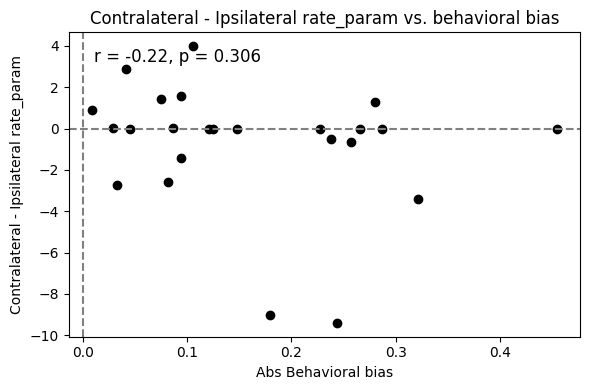

In [129]:
plot_contra_ipsi_rate_param_vs_bias(session_stats, mode='rate_param', color_by_sign_consistency=False)

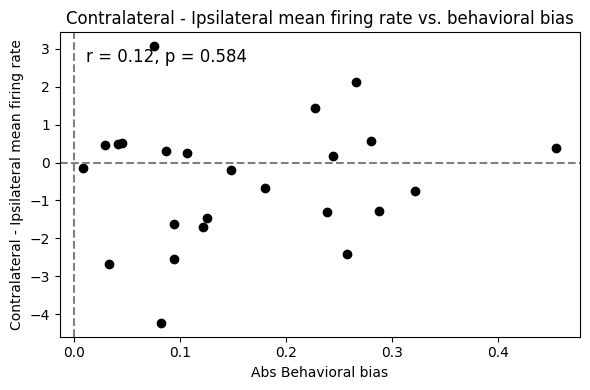

In [130]:
plot_contra_ipsi_rate_param_vs_bias(session_stats, mode='mean', color_by_sign_consistency=False)